In [8]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.2 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 21.3 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 29.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 35.6 MB/s  0:00:00

   ----- --------------------------------

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [11]:
df = pd.read_csv("Downloads/music_streams.csv")

In [12]:
df.head

<bound method NDFrame.head of       track_id                  title                          artist  \
0     TRK00001               Memories                   Juno Calloway   
1     TRK00002                  Tears                       Cleo Nova   
2     TRK00003                   Soul    Cole Voss ft. Indigo Ashford   
3     TRK00004                  Heart                    Asha Ashford   
4     TRK00005                  Bones                     Theo Blaine   
...        ...                    ...                             ...   
1195  TRK01196     Shattered Mind Now        Sage Lowe ft. Petra Kade   
1196  TRK01197           Golden Skies                    Iron Lullaby   
1197  TRK01198        Hollow Eyes Now                     Kai Hartley   
1198  TRK01199   Lonely Blues Tonight  Soren Laurent ft. Ember Pierce   
1199  TRK01200  Reckless World Inside        Zoe Kade ft. Remy Steele   

        genre  year duration  duration_sec  tempo_bpm       key  energy  ...  \
0         R&B

In [13]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='str')

In [18]:
df.describe

<bound method NDFrame.describe of       track_id                  title                          artist  \
0     TRK00001               Memories                   Juno Calloway   
1     TRK00002                  Tears                       Cleo Nova   
2     TRK00003                   Soul    Cole Voss ft. Indigo Ashford   
3     TRK00004                  Heart                    Asha Ashford   
4     TRK00005                  Bones                     Theo Blaine   
...        ...                    ...                             ...   
1195  TRK01196     Shattered Mind Now        Sage Lowe ft. Petra Kade   
1196  TRK01197           Golden Skies                    Iron Lullaby   
1197  TRK01198        Hollow Eyes Now                     Kai Hartley   
1198  TRK01199   Lonely Blues Tonight  Soren Laurent ft. Ember Pierce   
1199  TRK01200  Reckless World Inside        Zoe Kade ft. Remy Steele   

        genre  year duration  duration_sec  tempo_bpm       key  energy  ...  \
0        

## Histogram
Monthly Streams

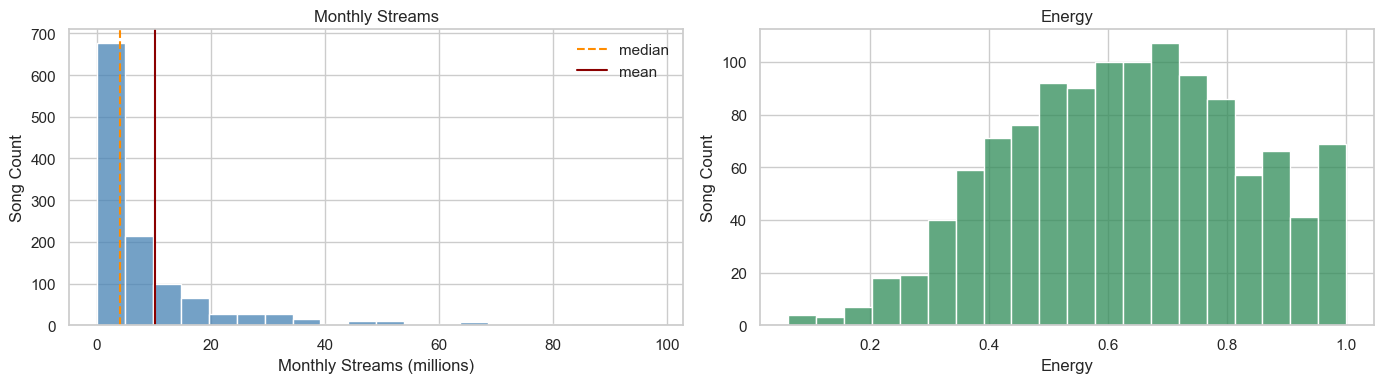

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

median = df.streams_millions.median()
mean = df.streams_millions.mean()

sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins=20,
             ax=ax1, color="steelblue")
ax1.axvline(median, color="darkorange", linestyle="--", label="median")
ax1.axvline(mean, color="darkred", label="mean")
ax1.legend(frameon=False)
ax1.set_xlabel("Monthly Streams (millions)")
ax1.set_ylabel("Song Count")
ax1.set_title("Monthly Streams")

sns.histplot(data=df, x="energy", bins=20, ax=ax2, color="seagreen")
ax2.set_xlabel("Energy")
ax2.set_ylabel("Song Count")
ax2.set_title("Energy")

plt.tight_layout()
plt.show()

## Box Plots

In [40]:
order = df.groupby("genre")["energy"]. median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='str', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

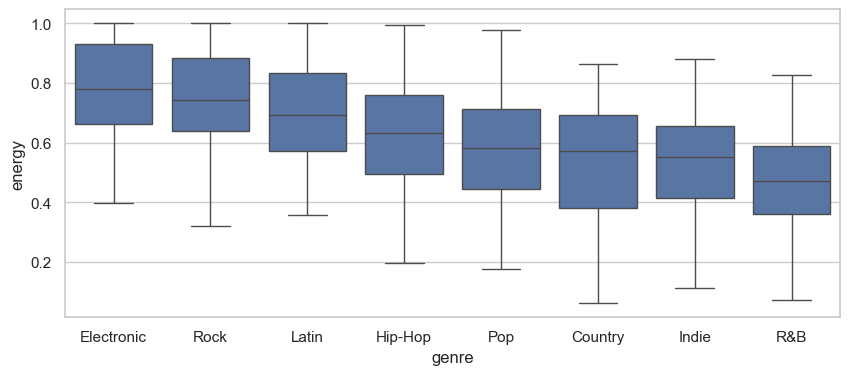

In [46]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y="energy", x="genre", order=order, ax=ax)

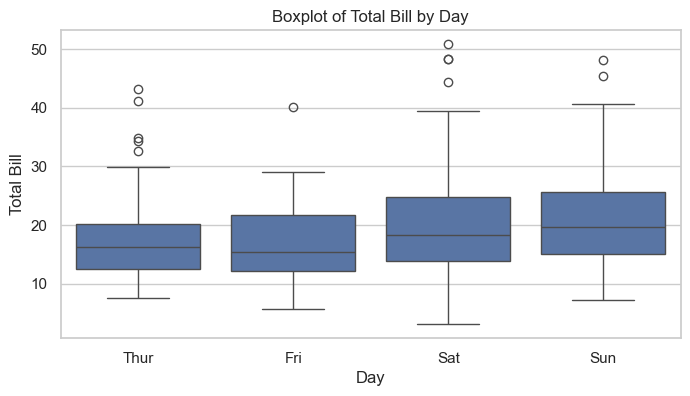

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=tips, x="day", y="total_bill", ax=ax)
ax.set_title("Boxplot of Total Bill by Day")
ax.set_xlabel("Day")
ax.set_ylabel("Total Bill")
plt.show()

## SCATTERPLOT

<Axes: xlabel='energy', ylabel='danceability'>

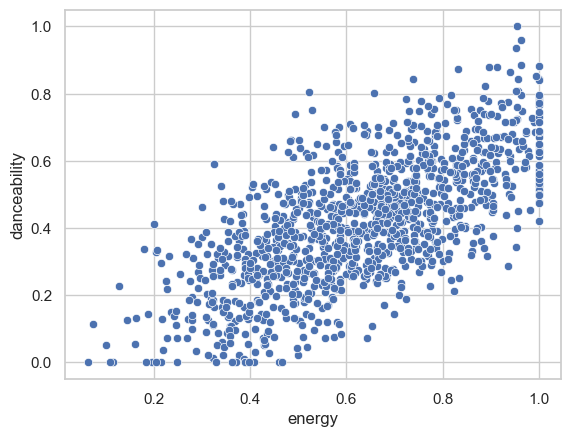

In [50]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x="energy", y= "danceability", hue="genre", color="grey", alpha = 0.5, patelle
sns.scatterplot(data=df, x="energy", y="danceability")

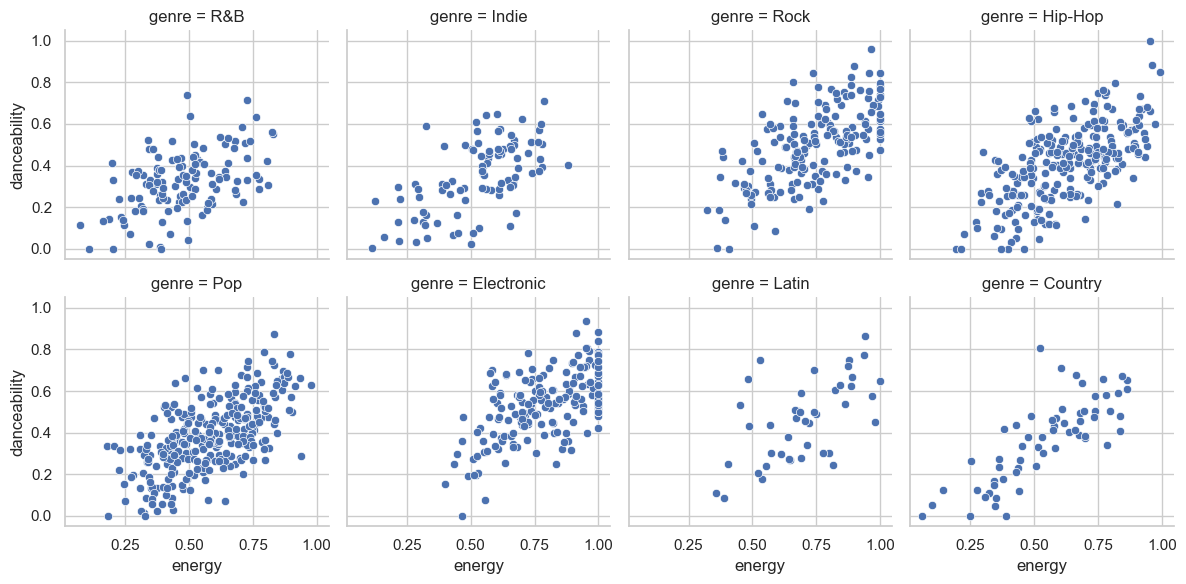

In [53]:
g=sns.FacetGrid(df,col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

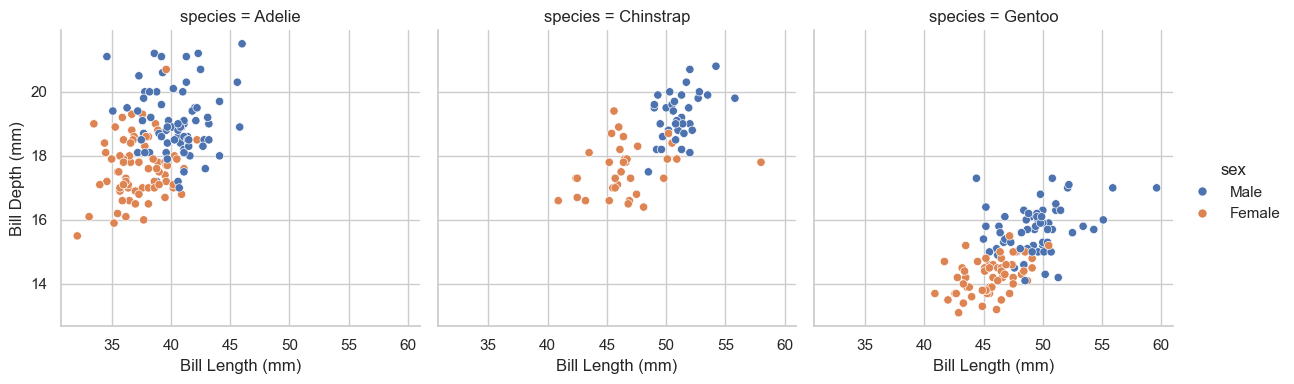

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")

g = sns.relplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    col="species",
    hue="sex",
    kind="scatter",
    height=4,
    aspect=1
)

g.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
g.set_titles("species = {col_name}")

plt.show()

In [55]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [ ]:
pop_trend = df[

    year       genre  streams_millions
0   2015  Electronic             6.040
1   2015     Hip-Hop             5.755
2   2015       Indie            13.900
3   2015         Pop             7.160
4   2015         R&B             3.590
5   2015        Rock             4.800
6   2016  Electronic             5.520
7   2016     Hip-Hop             5.650
8   2016       Indie             3.720
9   2016         Pop             3.540
10  2016         R&B             5.840
11  2016        Rock             5.390
12  2017  Electronic             4.120
13  2017     Hip-Hop             4.660
14  2017       Indie             2.130
15  2017         Pop             3.560
16  2017         R&B             3.910
17  2017        Rock             5.150
18  2018  Electronic             4.180
19  2018     Hip-Hop             4.590
20  2018       Indie             6.385
21  2018         Pop            11.370
22  2018         R&B             5.520
23  2018        Rock             3.060
24  2019  Electronic     

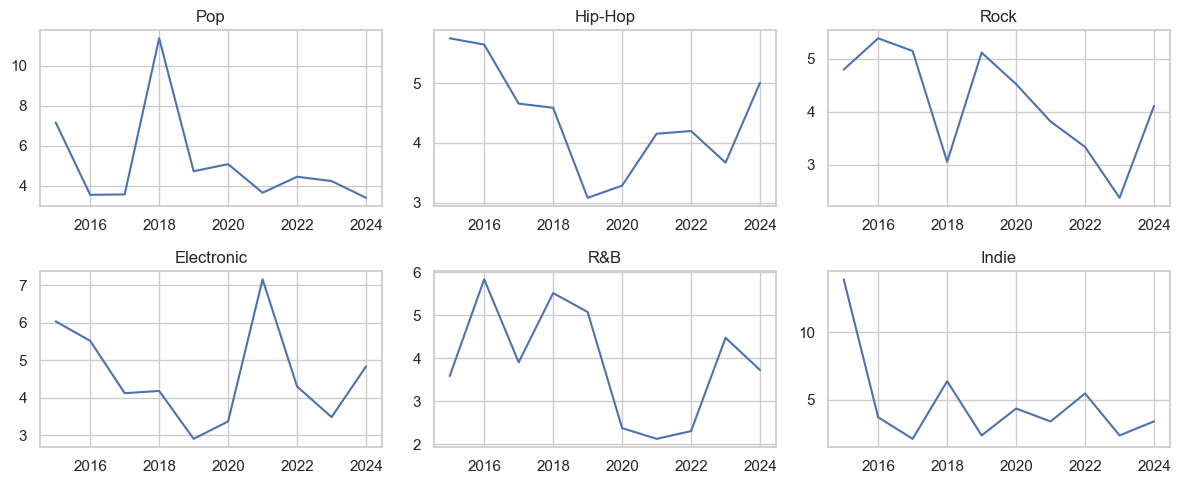

In [62]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = (df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index())
print(trend)
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()
for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    print(subD)
    ax.plot(subD.year, subD.streams_millions)
    ax.set_title(genre)
plt.tight_layout()
plt.show()

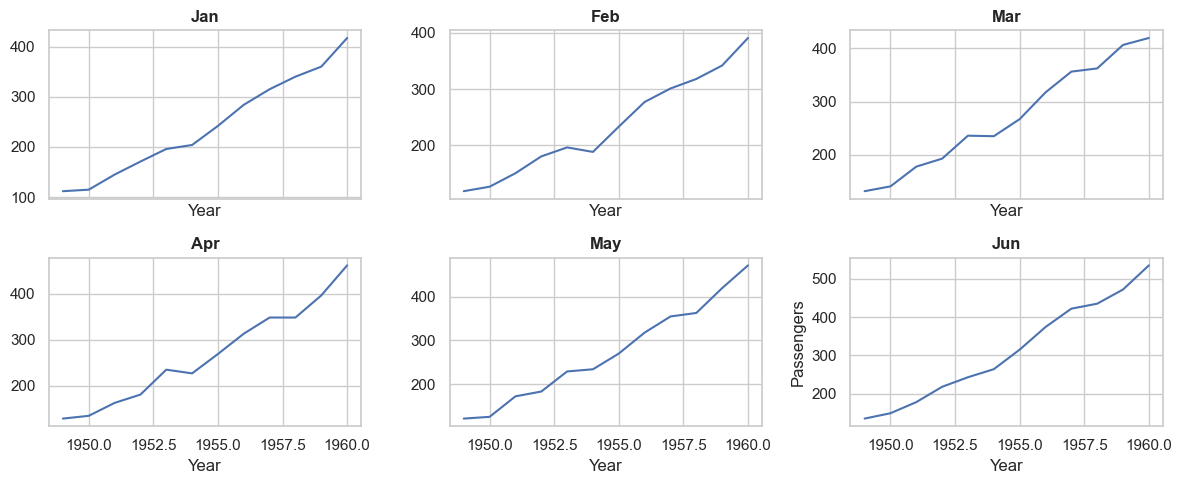

In [65]:
flights = sns.load_dataset("flights")
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
trend = flights[flights["month"].isin(months)]
fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
axes = axes.flatten()
for ax, month in zip(axes, months):
    sub = trend[trend["month"] == month]
    ax.plot(sub["year"], sub["passengers"])
    ax.set_title(month, fontweight="bold")
    ax.set_xlabel("Year")
ax.set_ylabel("Passengers")
plt.tight_layout()
plt.show()

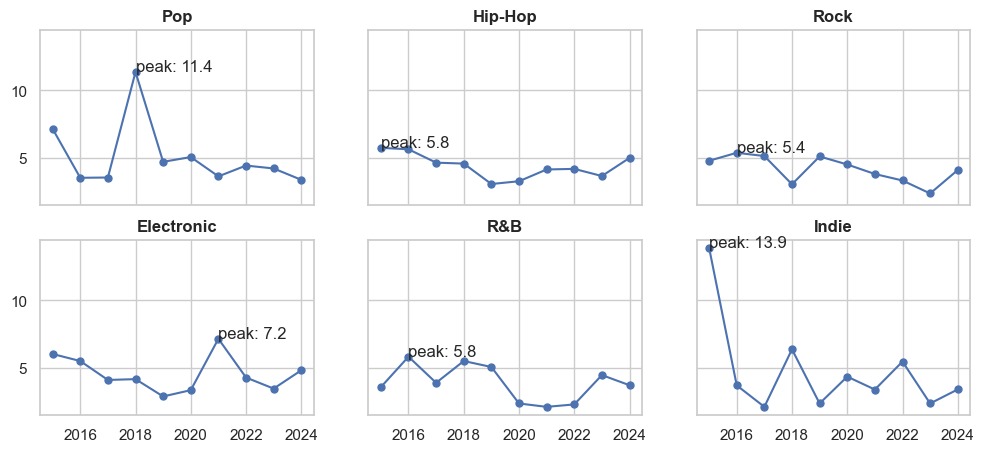

In [66]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()
fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f}", xy=(peak.year, peak.streams_millions))
    ax.set_title(genre, fontweight="bold")

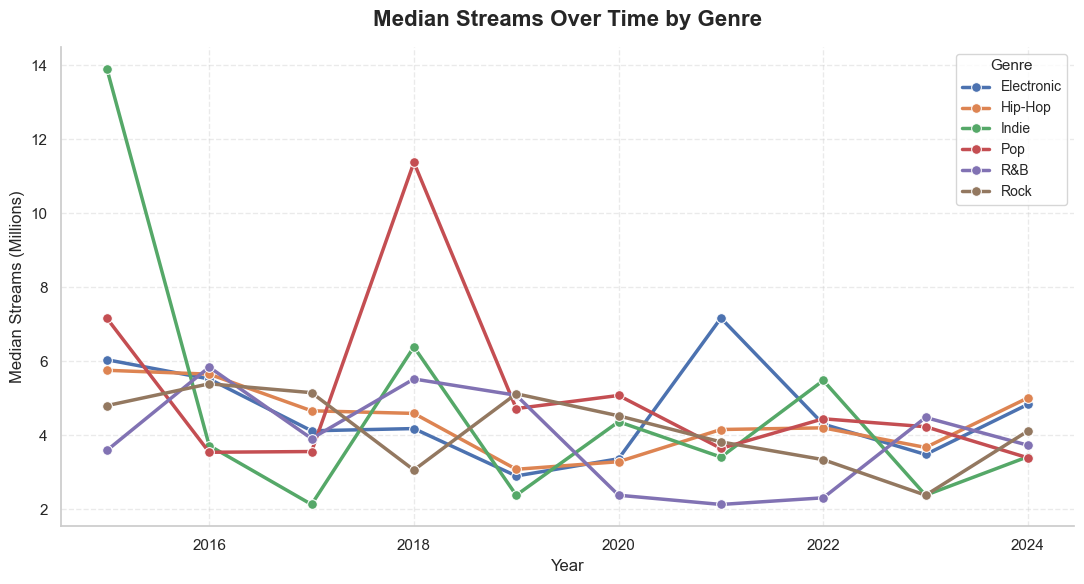

In [72]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]
trend = (
    df[df.genre.isin(genres)]
    .groupby(["year", "genre"])["streams_millions"]
    .median()
    .reset_index())
sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=trend,
    x="year",
    y="streams_millions",
    hue="genre",
    marker="o",
    linewidth=2.5,
    markersize=7,
    ax=ax
)
ax.set_title(
    "Median Streams Over Time by Genre",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Median Streams (Millions)", fontsize=12)
ax.legend(
    title="Genre",
    title_fontsize=11,
    fontsize=10,
    loc="upper right",
    frameon=True
)
ax.grid(True, linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [75]:
!pip install altair

   ---------------------------------------- 0.0/797.0 kB ? eta -:--:--
   ---------------------------------------- 797.0/797.0 kB 33.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [altair]
   -------------------- ------------------- 1/2 [altair]
   ---------------------------------------- 2/2 [altair]



In [77]:
import altair as alt
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]
trend = (
    df[df.genre.isin(genres)]
    .groupby(["year", "genre"])["streams_millions"]
    .median()
    .reset_index()
)
chart = (
    alt.Chart(trend)
    .mark_line(point=True)
    .encode(
        x=alt.X("year:O", title="Year"),
        y=alt.Y("streams_millions:Q", title="Median Streams (Millions)"),
        color=alt.Color("genre:N", title="Genre"),
        tooltip=[
            alt.Tooltip("year:O", title="Year"),
            alt.Tooltip("genre:N", title="Genre"),
            alt.Tooltip("streams_millions:Q", title="Median Streams", format=".2f")
        ]
    )
    .properties(
        width=650,
        height=400,
        title="Median Streams Over Time by Genre"
    )
    .configure_title(
        fontSize=18,
        fontWeight="bold",
        anchor="start"
    )
    .configure_axis(
        labelFontSize=12,
        titleFontSize=13
    )
    .configure_legend(
        titleFontSize=12,
        labelFontSize=11
    )
)
chart

alt.Chart(...)